# Importing OpenCV and Python Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Building CNN from Scratch

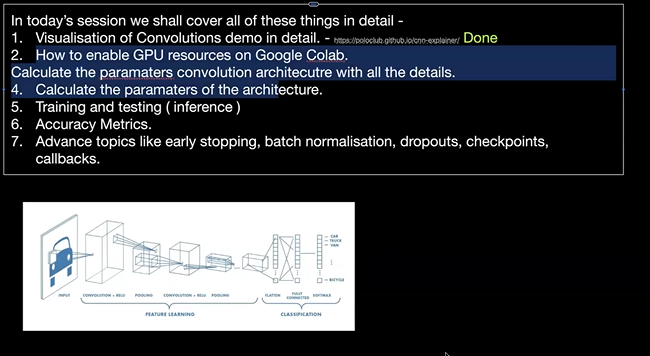

In [ ]:
!mkdir -p ./kaggle                   # we are creating a directory

In [ ]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle/
# Copy the kaggle.json file to the .kaggle directory
# You will need to upload the kaggle.json file to your Colab environment first
!cp kaggle.json ~/.kaggle/
# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogs-vs-cats")

print("Path to dataset files:", path)

In [ ]:
train_dir = '/kaggle/input/dogs-vs-cats/train'
validation_dir = '/kaggle/input/dogs-vs-cats/test'

In [ ]:
!pip install tensorflow numpy matplotlib keras

# Importing Packages

In [ ]:
import os

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

# Reading the data

# Data Analysis

In [ ]:
cat_directory_path = os.path.join(train_dir, 'cats')  #This line constructs the full path to the directory containing cat images by joining the train_dir path (which you defined earlier) with the folder name 'cats'.
dog_directory_path = os.path.join(train_dir, 'dogs')

cat_images = os.listdir(cat_directory_path)           # Similarly, this line constructs the full path to the directory containing cat images.
dog_images = os.listdir(dog_directory_path)

classes_animals = ['Cats', 'Dogs']
count = [len(cat_images), len(dog_images)]

print(count)

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
cat_image = '/kaggle/input/dogs-vs-cats/train/cats/cat.100.jpg'

img = cv2.imread(cat_image)
img

In [ ]:
cat_image = '/kaggle/input/dogs-vs-cats/train/cats/cat.100.jpg'    # this store the link that has the cat image ( but it does not store the image it self )


img = cv2.imread(cat_image)        # to ge the image , we have to Use OpenCV ( cv2) - but the problem with openCV is it stores the  image in BGR form

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # this converts BGR image to RGB so that we can see colors of the image
img_rgb    # we are printing the image


In [ ]:
cat_image = '/kaggle/input/dogs-vs-cats/train/cats/cat.2981.jpg'    # this store the link that has the cat image ( but it does not store the image it self )


img = cv2.imread(cat_image)        # to ge the image , we have to Use OpenCV ( cv2) - but the problem with openCV is it stores the  image in BGR form

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # this converts BGR image to RGB so that we can see colors of the image
img_rgb    # we are printing the image

In [ ]:
dog_image = '/kaggle/input/dogs-vs-cats/train/dogs/dog.1110.jpg'    # this store the link that has the dog image ( but it does not store the image it self )

img = cv2.imread(dog_image)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb

In [ ]:
dog_image = '/kaggle/input/dogs-vs-cats/train/dogs/dog.2310.jpg'    # this store the link that has the dog image ( but it does not store the image it self )

img = cv2.imread(dog_image)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb

In [ ]:
print(img)  # array of the image that we got from open CV  ( bgr image )

In [ ]:
print(img_rgb)  # printing the Rgb image's array

# Plotting the Data

In [ ]:
# Setting up a figure and axes for two subplots: one for the bar chart, one for the pie chart
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Bar chart on the first subplot
ax[0].bar(classes_animals, count, color=['blue', 'green'])
ax[0].set_xlabel('Animal Class')
ax[0].set_ylabel('Image Count')
ax[0].set_title('Count of Cat and Dog Images')

# Pie chart on the second subplot
colors = ['#ff9999','#66b3ff']
ax[1].pie(count, labels=classes_animals, colors=colors, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Distribution of Cat and Dog Images')
ax[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.


plt.tight_layout()      # adjust the layout
plt.show()


# Recaling the image

We so this so that we get more variation of picture ... thus having more pictures and decrease overfitting

20k Images
80 perc  - 16k
20 perc - 4k

In [ ]:
base_dir = '/kaggle/input/dogs-vs-cats'        # calling the api and getting ti in a directory base_dir

base_dir = os.path.join('/kaggle/input/dogs-vs-cats', 'train')

train_datagen = ImageDataGenerator(
    rescale= 1./255,             # rescaling because instead of doing from 1 to 255 we do it from 0 to 1 ( we normalized it )
    validation_split=0.2         # validation split 20 perc
    )

In [ ]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),

    batch_size=32,       # batch size

    class_mode='binary',
    subset='training'                             # set as training data
)

In [ ]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,                               # use same directory as training data
    target_size=(150, 150),

    batch_size=32,

    class_mode='binary',
    subset='validation',          # set as validation data

    shuffle=False
)

#  Print the image using OpenCV and python


## OpenCV 2

# Bulding the Model

In [ ]:
# Accessing class labels for the training data
train_class_labels = train_generator.class_indices
print("Training class labels:", train_class_labels)


# Accessing class labels for the validation data
validation_class_labels = validation_generator.class_indices
print("Validation class labels:", validation_class_labels)

Value of the images is shown after the Normalization has taken place & it also shows which label it belongs to :

In [ ]:
images, labels = next(train_generator)
images, labels

# CNN MODEL

In [ ]:
from tensorflow import keras
from keras import layers
from keras import models

model = models.Sequential([

     # Layer 1 ( Input layer)

    layers.Conv2D(filters = 128 ,               #Changed from layers.conv2D to layers.Conv2D
                  kernel_size = (3,3),        # kernel size - kernel is the one that going to do Convolutions
                  activation = 'relu',          # Activation - Relu
                  input_shape = (150 , 150,3 )),     # we have resized image to a standard 150 x 150

    layers.MaxPooling2D((2,2)),

    # Layer 2
    layers.Conv2D(filters = 64 ,                #Changed from layers.conv2D to layers.Conv2D
                  kernel_size = (3,3),         # now kernel size is 4,
                  activation = 'relu'),

    layers.MaxPooling2D((2,2)),

    # Layer 3
    layers.Conv2D(filters = 32,                #Changed from layers.conv2D to layers.Conv2D
                  kernel_size = (3,3),
                  activation = 'relu'),

    layers.MaxPooling2D((2,2)),

    # Layer 4
    layers.Conv2D(filters = 16,                #Changed from layers.conv2D to layers.Conv2D
                  kernel_size = (3,3),
                  activation = 'relu'),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),       # flatten


    layers.Dense(512, activation = 'relu'),     # dense

    layers.Dense(1, activation = 'sigmoid')           # we have binary Classification thats why We use Sigmoid as Activation function


]
)
model.summary()

#Fitting the model

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
              )

In [ ]:
history = model.fit(train_generator,
                     epochs = 10,
                    validation_data = validation_generator)

# Plotting the Training accuracy & Validation accuracy

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Model Evaluation

##Initial Test generator

In [ ]:
# Define the test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_dir = '/kaggle/input/dogs-vs-cats/test'  # Path to your test directory

# Create the test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),  # Should match the input size of your network
    batch_size=20,               # Can adjust based on your memory constraints
    class_mode='binary')

In [ ]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))

print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

## Test probablities

In [ ]:
np.ceil(test_generator.samples/test_generator.batch_size)

In [ ]:
probabilities = model.predict(test_generator)
probabilities

In [ ]:
probabilities = model.predict(test_generator,
                              steps=int(np.ceil(test_generator.samples/test_generator.batch_size)))
probabilities

## Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get the true labels from the test generator
true_classes = test_generator.classes

# Get the predicted classes from the model
# Predict probabilities for the test set
probabilities = model.predict(test_generator, steps=len(test_generator))

# Convert probabilities to binary predictions (0 or 1)
predicted_classes = (probabilities > 0.5).astype(int)

# Get the class labels from the test generator
class_labels = list(test_generator.class_indices.keys())

# Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plotting with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Prediction for a Single image ( Manual Testing )

In [ ]:
def make_prediction(image_path):
    img = load_img(img_path, target_size=(150, 150))  # Resizing the image
    img_array = img_to_array(img)  # Converting to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255             # Rescale the image similarly as we did for the training data

    prediction = model.predict(img_array)
    print("Prediction:", prediction)

    # printing the original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # Prediction
    plt.subplot(1, 2, 2)
    if prediction[0][0] > 0.5:
        plt.title('Predicted: Dog')
    else:
        plt.title('Predicted: Cat')


    #predicted image
    plt.imshow(img)  # Show the same image as prediction
    plt.axis('off')

    plt.show()

In [ ]:

img_path = '/content/bui bui.jpg'      # image path
make_prediction(img_path)

# 2nd prediction

In [ ]:

img_path = '/content/cato.jpeg'      # image path
make_prediction(img_path)